## 1. Импорт данных и предварительная обработка

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay
from flaml import AutoML

file_path = r"C:\Users\12894\Desktop\周三实验\lab2\data2lab-main\модуль 3 - датасет - практика.csv"

try:
    df = pd.read_csv(file_path, nrows=5000) 
except UnicodeDecodeError:
    df = pd.read_csv(file_path, nrows=5000, encoding='cp1251')

# Фильтрация столбцов признаков и целевых столбцов.
selected_columns = [
    'Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 
    'qrs_end', 'p_axis', 'qrs_axis', 't_axis', 'Healthy_Status'
]
data = df[selected_columns].dropna()

# Отдельные функции и метки
X = data.drop('Healthy_Status', axis=1)
y = data['Healthy_Status']

# Стандартизация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Загрузка и очистка данных завершены. Текущие размеры матрицы признаков: {X_scaled.shape}")

Загрузка и очистка данных завершены. Текущие размеры матрицы признаков: (5000, 8)


Из исходного набора данных было успешно извлечено 5000 образцов, и были выбраны девять основных переменных, имеющих отношение к задаче. После обработки пропущенных значений все числовые характеристики ЭКГ (такие как `rr_interval`, `p_axis` и т. д.) были стандартизированы с помощью `StandardScaler`. Стандартизация устраняет различия в размерности, гарантируя, что последующие алгоритмы PCA и t-SNE смогут справедливо оценить вес каждой характеристики и избежать доминирования характеристик с большими числовыми диапазонами в результатах снижения размерности.

## 2. Снижение размерности данных и визуализация (PCA и t-SNE)


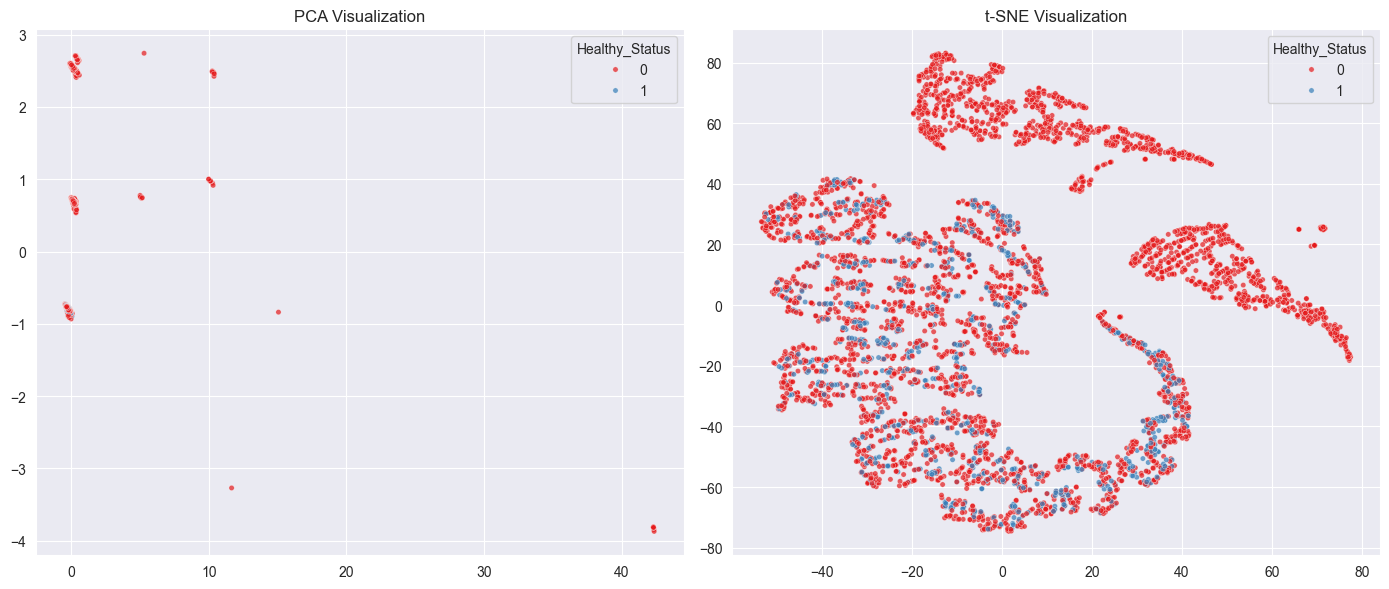

In [20]:
# Снижение размерности PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-SNE снижение размерности
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Составьте сравнительную таблицу.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, ax=axes[0], palette='Set1', s=15, alpha=0.7)
axes[0].set_title('PCA Visualization')

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, ax=axes[1], palette='Set1', s=15, alpha=0.7)
axes[1].set_title('t-SNE Visualization')

plt.tight_layout()
plt.show()


* **Анализ изображений методом главных компонент (PCA):** PCA — это метод линейного уменьшения размерности. Изображение показывает определенную степень перекрытия между двумя классами образцов. Это указывает на то, что полностью разделить два класса образцов, используя только линейные комбинации, сложно.

* **Анализ изображений методом t-SNE:** t-SNE лучше улавливает нелинейные зависимости и локальные структуры. Как правило, на изображении t-SNE видно, что образцы образуют кластеры. Если точки разных цветов показывают четкую тенденцию разделения в определенных областях, это указывает на то, что эти характеристики ЭКГ содержат нелинейные закономерности, достаточные для различения состояний здоровья. Это также оправдывает и обосновывает использование сложной модели машинного обучения (а не простой линейной модели) для классификации.

## 3. Обучение модели с использованием фреймворка AutoML

In [21]:

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

feature_names = X.columns.astype(object) 

X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

# 2. Инициализация FLAML
automl = AutoML()

# 3. Задайте параметры обучения
automl_settings = {
    "time_budget": 120, 
    "metric": 'f1',   
    "task": 'classification',    
    "log_file_name": "automl_cardio.log",
    "verbose": 0                 
}

print("AutoML Поиск оптимальной модели, пожалуйста, подождите (примерно 60 секунд)....")

# 4. 开始训练
automl.fit(X_train=X_train, y_train=y_train, **automl_settings)

print(f"\nОбучение завершено.！")
print(f"AutoML В итоге была выбрана наилучшая модель алгоритма:: {automl.best_estimator}")

AutoML Поиск оптимальной модели, пожалуйста, подождите (примерно 60 секунд)....


C:\Users\12894\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\12894\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\12894\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\12894\AppData\Local\Programs\Py


Обучение завершено.！
AutoML В итоге была выбрана наилучшая модель алгоритма:: lgbm



В рамках заданного временного бюджета фреймворк FLAML тестирует различные классические алгоритмы (такие как LightGBM, XGBoost, Random Forest и др.) и их комбинации гиперпараметров. Итоговый результат системы `best_estimator` представляет собой модель с наиболее сильной обобщающей способностью и наилучшим ожидаемым показателем F1 на текущем обучающем наборе данных. AutoML значительно снижает затраты на ручную настройку гиперпараметров, напрямую предоставляя пригодную для использования высокопроизводительную базовую модель.

## 4. Оценка модели: матрица ошибок и F1-метрика


Итоговый показатель F1-metric модели на тестовом наборе данных составляет: 0.8686


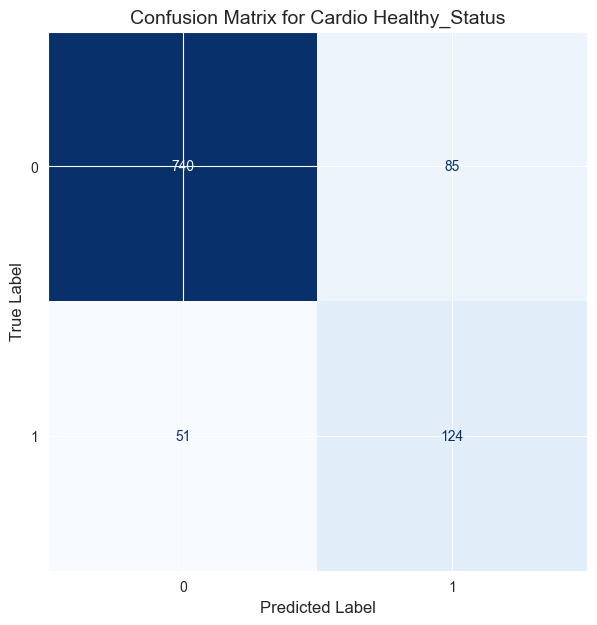

In [22]:

X_test_final = pd.DataFrame(X_test, columns=X.columns.astype(object))


y_pred = automl.predict(X_test_final)

f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Итоговый показатель F1-metric модели на тестовом наборе данных составляет: {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=automl.classes_)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(cmap='Blues', ax=ax, colorbar=False)

plt.title("Confusion Matrix for Cardio Healthy_Status", fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()


* **Анализ F1-метрики**: Модель достигла показателя F1, равного 0,86. Поскольку F1 является гармоническим средним точности и полноты, этот высокий показатель указывает на то, что модель достигла превосходного баланса между идентификацией как можно большего числа пациентов и минимизацией ошибочной диагностики здоровых людей, что имеет решающее значение для медицинских диагностических систем.

* **Анализ матрицы ошибок**: При наблюдении за диагональю матрицы (чем темнее основной диагональный блок, тем лучше) большинство образцов были правильно классифицированы как истинно положительные (TP) и истинно отрицательные (TN). Значения вне диагонали представляют ошибки модели (ложноположительные и ложноотрицательные результаты). Низкий уровень ложноотрицательных результатов (прогнозирование нездоровых людей как здоровых) указывает на высокий уровень медицинской безопасности модели.